   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00
Using device: cuda
✅ Part C : /kaggle/input/datasets/peesarisathvikreddy/isic2018-seg-part-c
✅ ISIC   : /kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation

Checking key files:
  ✅ meta.json
  ✅ test_df.csv
  ✅ train_df.csv
  ✅ fl_results_all_methods.csv
  ✅ final_model_fedavg.pth
  ✅ final_model_weighted_fedavg.pth
  ✅ final_model_fedprox.pth
  ✅ final_model_ditto.pth
  ✅ client_0_train.csv
  ✅ client_1_train.csv
  ✅ client_2_train.csv
  ✅ client_0_test_split.csv
  ✅ client_1_test_split.csv
  ✅ client_2_test_split.csv

Methods in fl_results_all_methods.csv: ['fedavg', 'weighted_fedavg', 'ditto']
⚠️  FedProx round history missing — convergence plot will show 3 lines. Evaluation metrics unaffected.

Train:2075 | Test:519
Client sizes: [688, 687, 700]
Val:415 | Test:519

Using SMP U-Net


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Output shape: torch.Size([2, 1, 256, 256])

Loading FL models...
  ✅ fedavg → Dice=0.8742  IoU=0.8019
  ✅ weighted_fedavg → Dice=0.8741  IoU=0.8018
  ✅ fedprox → Dice=0.8738  IoU=0.8005
  ✅ ditto → Dice=0.8703  IoU=0.7979

Training centralized model (3 epochs)...


Centralized → Dice=0.8860  IoU=0.8147

Training local-only models...


  C0 (Small lesions) → Dice=0.8482  IoU=0.7536


  C1 (Medium lesions) → Dice=0.7023  IoU=0.5855


  C2 (Large lesions) → Dice=0.7160  IoU=0.6079

===== FINAL TEST METRICS =====
Method                    Dice     IoU      Sens     Spec     PxAcc   
--------------------------------------------------------------------
Centralized               0.8860   0.8147   0.9066   0.9741   0.9538
Best Local (C0)           0.8482   0.7536   0.9200   0.9448   0.9377
fedavg                    0.8742   0.8019   0.8772   0.9754   0.9504
weighted_fedavg           0.8741   0.8018   0.8711   0.9777   0.9509
fedprox                   0.8738   0.8005   0.8647   0.9778   0.9499
ditto                     0.8703   0.7979   0.8754   0.9729   0.9487

✅ Best FL (fedavg) vs local: 3.1% improvement


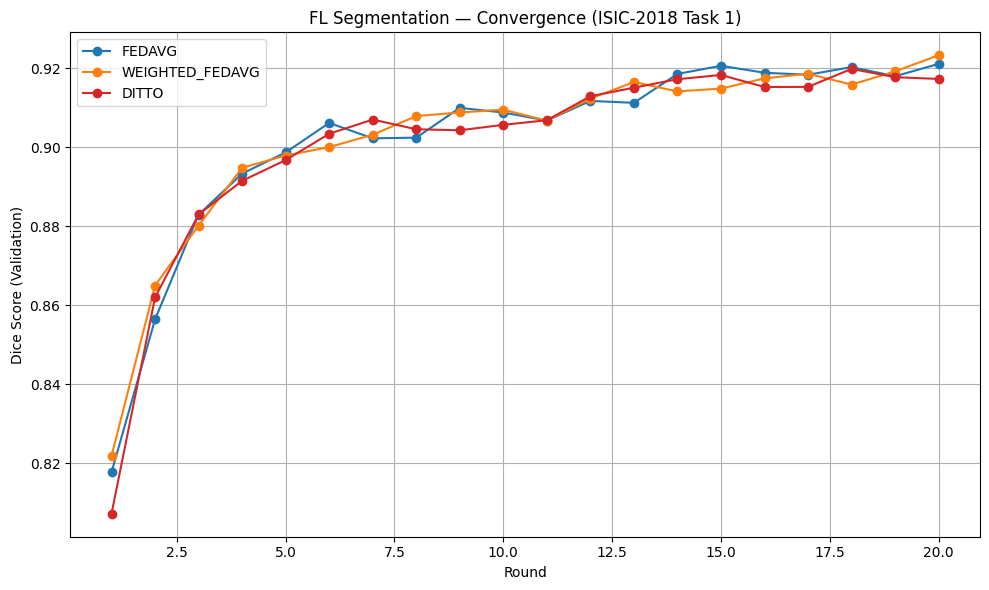


Generating masks (FEDAVG)...


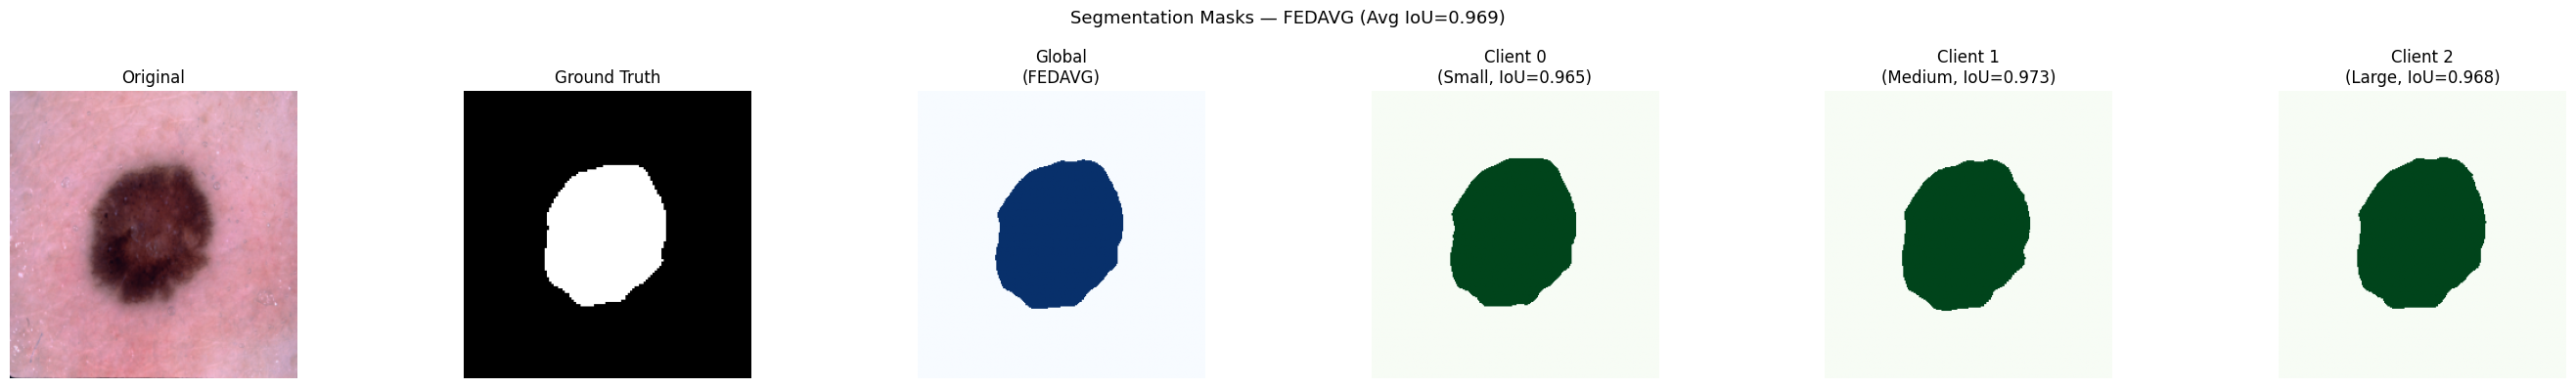

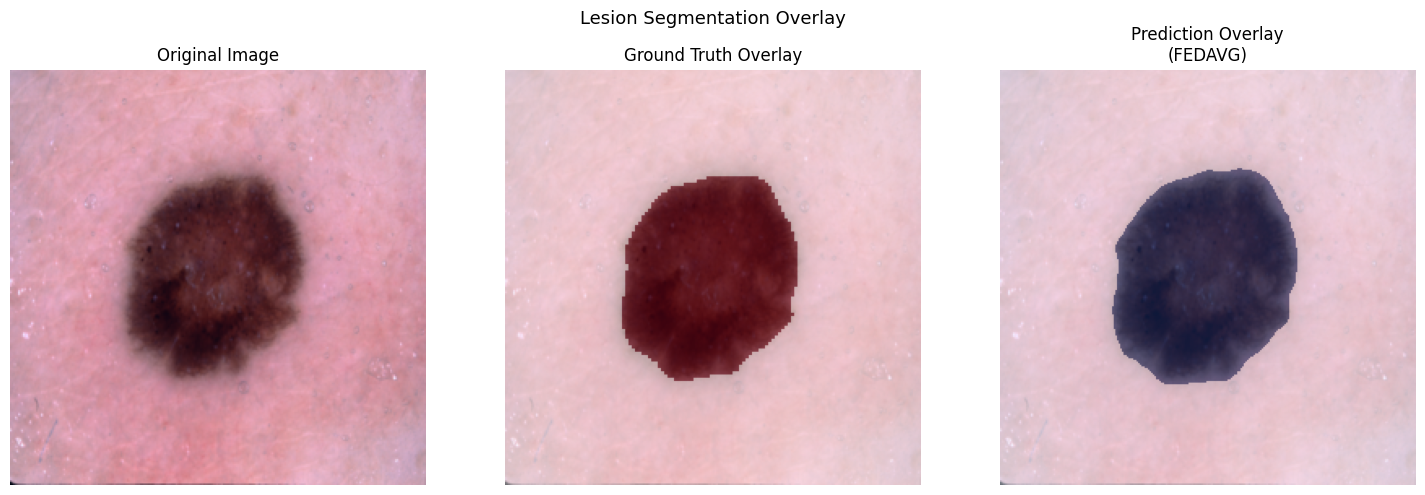

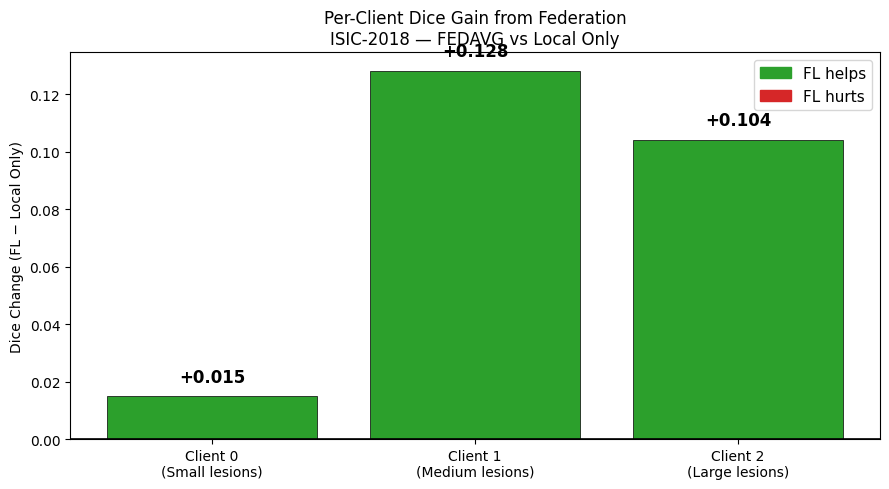

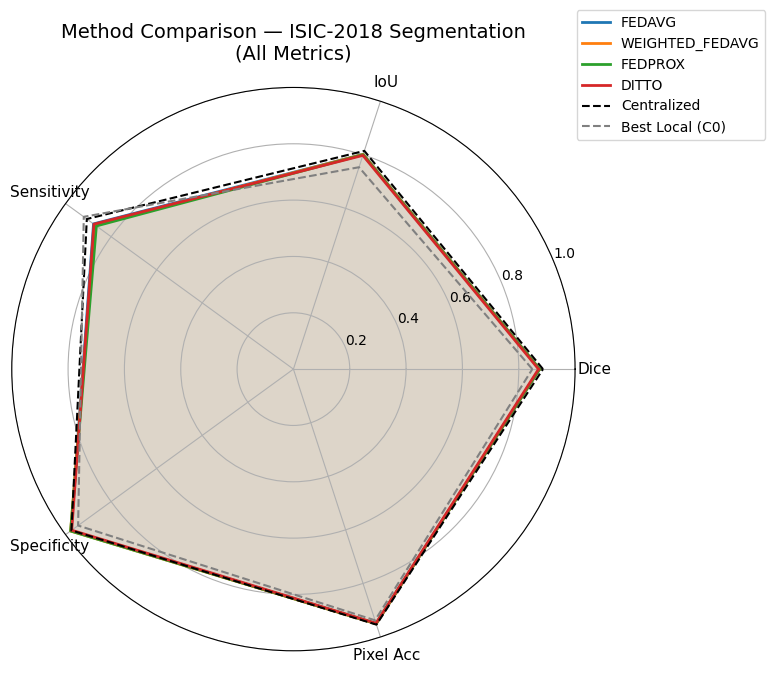

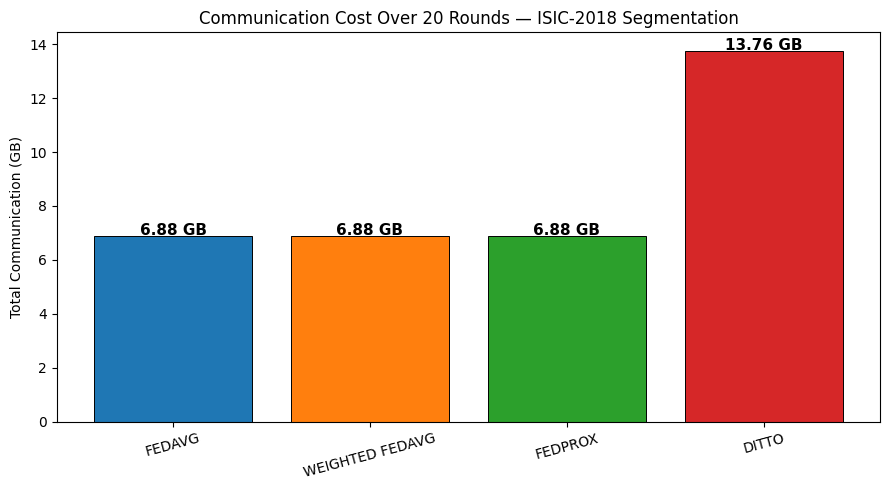


MACHINE UNLEARNING
Forgetting: Client 2 (Large lesions)
Base model: FEDAVG

Before unlearning:
  Forget C2 Dice  : 0.9064
  Retain C0 Dice  : 0.9465
  Retain C1 Dice  : 0.9029
  Global Dice     : 0.8742

--- Approach A: Exact Unlearning (10 rounds, no C2) ---
  Round 1/10 → val Dice:0.8393
  Round 2/10 → val Dice:0.8664
  Round 3/10 → val Dice:0.8904
  Round 4/10 → val Dice:0.8891
  Round 5/10 → val Dice:0.8859
  Round 6/10 → val Dice:0.8892
  Round 7/10 → val Dice:0.8969
  Round 8/10 → val Dice:0.8986
  Round 9/10 → val Dice:0.8977
  Round 10/10 → val Dice:0.9041
  Forget C2 Dice : 0.8535  (Δ=-0.0529)
  Retain C0 Dice : 0.9434
  Retain C1 Dice : 0.8868

--- Approach B: Gradient Ascent Unlearning ---
  Step 1: Gradient Ascent (50 steps)...
    Step 10: forget Dice=0.9039
    Step 20: forget Dice=0.9027
    Step 30: forget Dice=0.9009
    Step 40: forget Dice=0.8989
    Step 50: forget Dice=0.8967
  Step 2: Fine-tune on retain (3 epochs)...
    Epoch 1: val Dice=0.9470
    Epoch 2: val

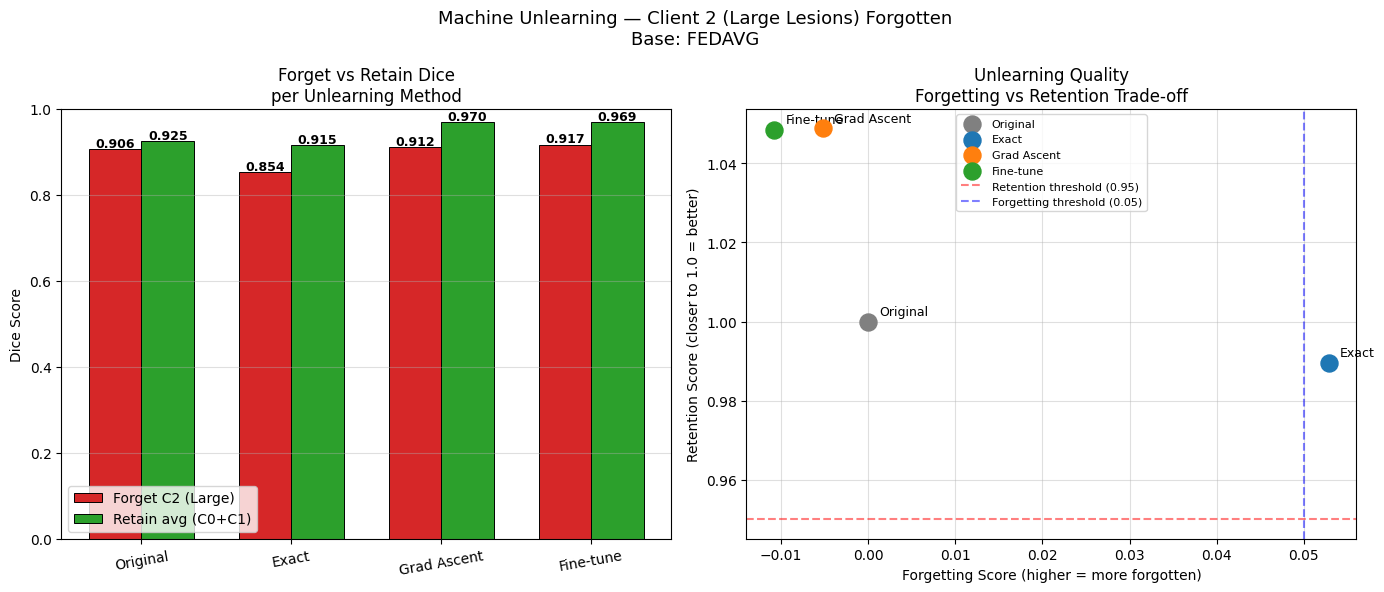

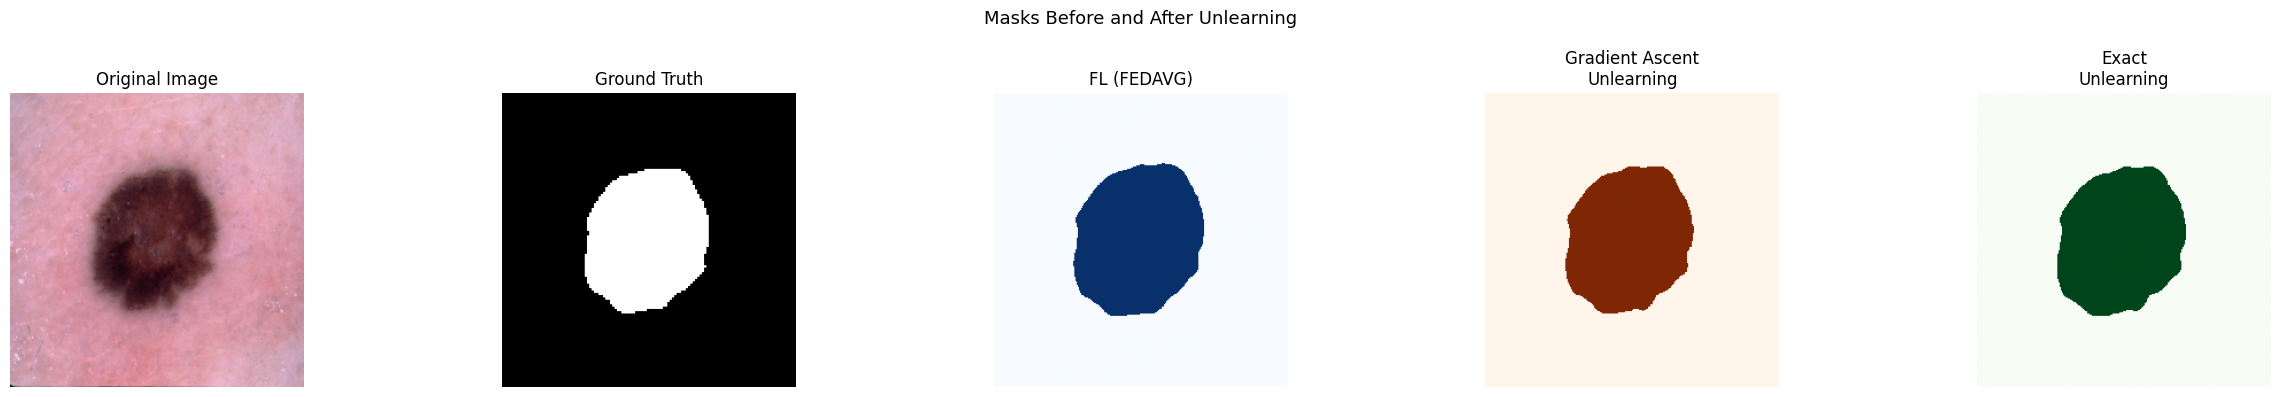


ALL OUTPUTS SAVED
  ✅ final_comparison_table.csv
  ✅ unlearning_results.csv
  ✅ communication_cost.csv
  ✅ convergence_all_methods.png
  ✅ mask_comparison.png
  ✅ mask_overlay.png
  ✅ mask_unlearning_comparison.png
  ✅ unlearning_comparison.png
  ✅ fl_gain_per_client.png
  ✅ radar_chart.png
  ✅ communication_cost.png


In [1]:
# ==========================================
# NOTEBOOK 2: FL SEGMENTATION VALIDATION
#             + MACHINE UNLEARNING
# Inputs: isic2018-seg-part-c + ISIC-2018
# ==========================================

!pip install -q scikit-learn tqdm segmentation-models-pytorch

import os, json, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from collections import OrderedDict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. HARDCODED PATHS
# ==========================================
PART_C    = "/kaggle/input/datasets/peesarisathvikreddy/isic2018-seg-part-c"
ISIC_PATH = "/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation"

TRAIN_IMG_DIR  = os.path.join(ISIC_PATH, "ISIC2018_Task1-2_Training_Input")
TRAIN_MASK_DIR = os.path.join(ISIC_PATH, "ISIC2018_Task1_Training_GroundTruth")

print(f"✅ Part C : {PART_C}")
print(f"✅ ISIC   : {ISIC_PATH}")

# Verify key files
print("\nChecking key files:")
for fname in [
    "meta.json","test_df.csv","train_df.csv",
    "fl_results_all_methods.csv",
    "final_model_fedavg.pth",
    "final_model_weighted_fedavg.pth",
    "final_model_fedprox.pth",
    "final_model_ditto.pth",
    "client_0_train.csv","client_1_train.csv","client_2_train.csv",
    "client_0_test_split.csv","client_1_test_split.csv",
    "client_2_test_split.csv",
]:
    exists = "✅" if os.path.exists(os.path.join(PART_C,fname)) else "❌"
    print(f"  {exists} {fname}")

# ==========================================
# 2. CHECK WHICH METHODS ARE IN HISTORY
# ==========================================
df_hist_check = pd.read_csv(
    os.path.join(PART_C,"fl_results_all_methods.csv"))
methods_in_csv = df_hist_check['aggregation'].unique().tolist()
print(f"\nMethods in fl_results_all_methods.csv: {methods_in_csv}")
if 'fedprox' not in methods_in_csv:
    print("⚠️  FedProx round history missing — convergence plot "
          "will show 3 lines. Evaluation metrics unaffected.")

# ==========================================
# 3. RELOAD META + DATA
# ==========================================
with open(os.path.join(PART_C,"meta.json")) as f:
    meta = json.load(f)

majority_classes_per_client = meta['majority_classes_per_client']
IMG_SIZE                    = meta['img_size']
MAIN_FRAC                   = meta['main_frac']

train_df   = pd.read_csv(os.path.join(PART_C,"train_df.csv"))
test_df    = pd.read_csv(os.path.join(PART_C,"test_df.csv"))
client_dfs = [pd.read_csv(os.path.join(PART_C,f"client_{i}_train.csv"))
              for i in range(3)]
client_sizes = [len(c) for c in client_dfs]

print(f"\nTrain:{len(train_df)} | Test:{len(test_df)}")
print(f"Client sizes: {client_sizes}")

# ==========================================
# 4. TRANSFORMS + DATASET
# ==========================================
img_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
mask_tf = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE),
        interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
])

class SegDataset(Dataset):
    def __init__(self, df, img_tf=None, mask_tf=None, noise=0.0):
        self.df=df.reset_index(drop=True)
        self.img_tf=img_tf; self.mask_tf=mask_tf; self.noise=noise
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        img=Image.open(row['image']).convert("RGB")
        mask=Image.open(row['mask']).convert("L")
        if self.img_tf:  img=self.img_tf(img)
        if self.mask_tf: mask=self.mask_tf(mask)
        mask=(mask>0.5).float()
        if self.noise>0:
            img+=torch.randn_like(img)*self.noise/255.0
            img=torch.clamp(img,0,1)
        return img, mask, row['size_label']

def make_loader(df, noise=0.0, batch_size=8, shuffle=False):
    return DataLoader(
        SegDataset(df, img_tf, mask_tf, noise),
        batch_size=batch_size, shuffle=shuffle,
        num_workers=2, pin_memory=True)

NOISE        = [0.0, 15.0, 10.0]
dataloaders  = [make_loader(cdf, noise=NOISE[i])
                for i, cdf in enumerate(client_dfs)]
val_df       = train_df.sample(frac=0.2, random_state=42)
val_loader   = make_loader(val_df)
test_dataset = SegDataset(test_df, img_tf, mask_tf)
test_loader  = make_loader(test_df)

client_test_loaders = [
    make_loader(pd.read_csv(
        os.path.join(PART_C,f"client_{i}_test_split.csv")))
    for i in range(3)
]
print(f"Val:{len(val_df)} | Test:{len(test_df)}")

# ==========================================
# 5. MODEL
# ==========================================
try:
    import segmentation_models_pytorch as smp
    def get_model():
        return smp.Unet(
            encoder_name="resnet18", encoder_weights="imagenet",
            in_channels=3, classes=1).to(device)
    print("\nUsing SMP U-Net")
except ImportError:
    class DoubleConv(nn.Module):
        def __init__(self,ic,oc):
            super().__init__()
            self.c=nn.Sequential(
                nn.Conv2d(ic,oc,3,padding=1,bias=False),
                nn.BatchNorm2d(oc),nn.ReLU(inplace=True),
                nn.Conv2d(oc,oc,3,padding=1,bias=False),
                nn.BatchNorm2d(oc),nn.ReLU(inplace=True))
        def forward(self,x): return self.c(x)
    class UNet(nn.Module):
        def __init__(self,features=[64,128,256,512]):
            super().__init__()
            self.downs=nn.ModuleList(); self.ups=nn.ModuleList()
            self.pool=nn.MaxPool2d(2); c=3
            for f in features: self.downs.append(DoubleConv(c,f)); c=f
            self.bottleneck=DoubleConv(features[-1],features[-1]*2)
            for f in reversed(features):
                self.ups.append(nn.ConvTranspose2d(f*2,f,2,stride=2))
                self.ups.append(DoubleConv(f*2,f))
            self.final=nn.Conv2d(features[0],1,1)
        def forward(self,x):
            skips=[]
            for d in self.downs: x=d(x); skips.append(x); x=self.pool(x)
            x=self.bottleneck(x); skips=skips[::-1]
            for i in range(0,len(self.ups),2):
                x=self.ups[i](x); sk=skips[i//2]
                if x.shape!=sk.shape: x=F.interpolate(x,size=sk.shape[2:])
                x=self.ups[i+1](torch.cat([sk,x],dim=1))
            return self.final(x)
    def get_model(): return UNet().to(device)
    print("\nUsing custom U-Net")

_m=get_model(); _x=torch.randn(2,3,IMG_SIZE,IMG_SIZE).to(device)
print(f"Output shape: {_m(_x).shape}"); del _m,_x
torch.cuda.empty_cache()

# ==========================================
# 6. LOSS + METRICS
# ==========================================
class DiceBCELoss(nn.Module):
    def __init__(self,smooth=1e-6):
        super().__init__()
        self.bce=nn.BCEWithLogitsLoss(); self.s=smooth
    def forward(self,logits,targets):
        bce=self.bce(logits,targets); p=torch.sigmoid(logits)
        i=(p*targets).sum(dim=(2,3))
        d=1-(2*i+self.s)/(p.sum(dim=(2,3))+targets.sum(dim=(2,3))+self.s)
        return bce+d.mean()

criterion = DiceBCELoss()

def compute_metrics(logits, masks, thr=0.5):
    preds=(torch.sigmoid(logits)>thr).float(); s=1e-6
    tp=(preds*masks).sum(dim=(2,3))
    fp=(preds*(1-masks)).sum(dim=(2,3))
    fn=((1-preds)*masks).sum(dim=(2,3))
    tn=((1-preds)*(1-masks)).sum(dim=(2,3))
    return {
        'dice':        ((2*tp+s)/(2*tp+fp+fn+s)).mean().item(),
        'iou':         ((tp+s)/(tp+fp+fn+s)).mean().item(),
        'pixel_acc':   ((tp+tn+s)/(tp+fp+fn+tn+s)).mean().item(),
        'sensitivity': ((tp+s)/(tp+fn+s)).mean().item(),
        'specificity': ((tn+s)/(tn+fp+s)).mean().item(),
    }

def evaluate(model, loader):
    model.eval(); all_m=[]
    with torch.no_grad():
        for batch in loader:
            imgs,masks=batch[0].to(device),batch[1].to(device)
            all_m.append(compute_metrics(model(imgs),masks))
    return {k:float(np.mean([m[k] for m in all_m])) for k in all_m[0]}

# ==========================================
# 7. LOAD ALL 4 FL MODELS
# ==========================================
METHOD_NAMES     = ['fedavg','weighted_fedavg','fedprox','ditto']
fl_models        = {}
fl_client_models = {}

print("\nLoading FL models...")
for name in METHOD_NAMES:
    gm=get_model()
    gm.load_state_dict(torch.load(
        os.path.join(PART_C,f"final_model_{name}.pth"),
        map_location=device))
    fl_models[name]=gm

    clist=[]
    for cid in range(3):
        cm=get_model()
        cm.load_state_dict(torch.load(
            os.path.join(PART_C,f"client_{name}_{cid}.pth"),
            map_location=device))
        clist.append(cm)
    fl_client_models[name]=clist
    m=evaluate(gm,test_loader)
    print(f"  ✅ {name} → Dice={m['dice']:.4f}  IoU={m['iou']:.4f}")

# ==========================================
# 8. CENTRALIZED BASELINE
# ==========================================
print("\nTraining centralized model (3 epochs)...")
c_loader = make_loader(train_df, batch_size=8, shuffle=True)
central  = get_model()
c_opt    = optim.Adam(central.parameters(), lr=1e-4)

for epoch in range(3):
    central.train()
    for batch in tqdm(c_loader,
                      desc=f"Central epoch {epoch+1}", leave=False):
        imgs,masks=batch[0].to(device),batch[1].to(device)
        c_opt.zero_grad()
        criterion(central(imgs),masks).backward()
        c_opt.step()

central_metrics = evaluate(central, test_loader)
print(f"Centralized → Dice={central_metrics['dice']:.4f}  "
      f"IoU={central_metrics['iou']:.4f}")
del c_loader; torch.cuda.empty_cache()

# ==========================================
# 9. LOCAL-ONLY BASELINES
# ==========================================
print("\nTraining local-only models...")
local_models, local_metrics = [], []

for cid, cdf in enumerate(client_dfs):
    loader = make_loader(cdf, noise=NOISE[cid],
                         batch_size=8, shuffle=True)
    model  = get_model()
    opt    = optim.Adam(model.parameters(), lr=1e-4)
    for epoch in range(3):
        model.train()
        for batch in tqdm(loader,
                          desc=f"Local C{cid} ep{epoch+1}",
                          leave=False):
            imgs,masks=batch[0].to(device),batch[1].to(device)
            opt.zero_grad()
            criterion(model(imgs),masks).backward()
            opt.step()
    m=evaluate(model, test_loader)
    local_models.append(model); local_metrics.append(m)
    print(f"  C{cid} ({['Small','Medium','Large'][cid]} lesions) → "
          f"Dice={m['dice']:.4f}  IoU={m['iou']:.4f}")
    del loader; torch.cuda.empty_cache()

# ==========================================
# 10. FINAL COMPARISON TABLE
# ==========================================
best_local_idx = int(np.argmax([m['dice'] for m in local_metrics]))
bl             = local_metrics[best_local_idx]

print("\n===== FINAL TEST METRICS =====")
print(f"{'Method':<25} {'Dice':<8} {'IoU':<8} "
      f"{'Sens':<8} {'Spec':<8} {'PxAcc':<8}")
print("-"*68)

table_data = []
rows = (
    [('Centralized',                     central_metrics),
     (f'Best Local (C{best_local_idx})', bl)] +
    [(n, evaluate(fl_models[n], test_loader)) for n in METHOD_NAMES]
)

for label,m in rows:
    print(f"{label:<25} {m['dice']:.4f}   {m['iou']:.4f}   "
          f"{m['sensitivity']:.4f}   {m['specificity']:.4f}   "
          f"{m['pixel_acc']:.4f}")
    table_data.append({'Method':label, **m})

pd.DataFrame(table_data).to_csv(
    "/kaggle/working/final_comparison_table.csv", index=False)

best_fl_name = max(METHOD_NAMES,
    key=lambda n: evaluate(fl_models[n],test_loader)['dice'])
best_fl_dice = evaluate(fl_models[best_fl_name],test_loader)['dice']
print(f"\n✅ Best FL ({best_fl_name}) vs local: "
      f"{(best_fl_dice-bl['dice'])/bl['dice']*100:.1f}% improvement")

# ==========================================
# 11. CONVERGENCE PLOT
# ==========================================
df_all = pd.read_csv(os.path.join(PART_C,"fl_results_all_methods.csv"))
colors = {'fedavg':'#1f77b4','weighted_fedavg':'#ff7f0e',
          'fedprox':'#2ca02c','ditto':'#d62728'}

plt.figure(figsize=(10,6))
for name in METHOD_NAMES:
    sub=df_all[df_all['aggregation']==name]
    if len(sub)>0:
        plt.plot(sub['round']+1, sub['dice'],
                 marker='o', color=colors[name], label=name.upper())
plt.xlabel('Round'); plt.ylabel('Dice Score (Validation)')
plt.title('FL Segmentation — Convergence (ISIC-2018 Task 1)')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("/kaggle/working/convergence_all_methods.png", dpi=150)
plt.show()

# ==========================================
# 12. MASK VISUALISATION
# ==========================================
print(f"\nGenerating masks ({best_fl_name.upper()})...")

def predict_mask(model, img_tensor, thr=0.5):
    model.eval()
    with torch.no_grad():
        logit=model(img_tensor.unsqueeze(0).to(device))
        return (torch.sigmoid(logit)>thr).squeeze().cpu().numpy()

def mask_iou(m1,m2):
    inter=np.logical_and(m1,m2).sum()
    union=np.logical_or(m1,m2).sum()
    return inter/union if union>0 else 1.0

sample_img, sample_mask, _ = test_dataset[0]
gt_mask    = sample_mask.squeeze().numpy()
orig       = sample_img.permute(1,2,0).numpy()
orig       = (orig-orig.min())/(orig.max()-orig.min())

global_pred  = predict_mask(fl_models[best_fl_name], sample_img)
client_preds = [predict_mask(cm, sample_img)
                for cm in fl_client_models[best_fl_name]]
client_ious  = [mask_iou(global_pred, cp) for cp in client_preds]
avg_iou_s    = float(np.mean(client_ious))

# Mask comparison
fig, axes = plt.subplots(1,6,figsize=(28,4))
axes[0].imshow(orig); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(gt_mask,cmap='gray')
axes[1].set_title('Ground Truth'); axes[1].axis('off')
axes[2].imshow(global_pred,cmap='Blues')
axes[2].set_title(f'Global\n({best_fl_name.upper()})'); axes[2].axis('off')
size_labels = ['Small','Medium','Large']
for i,(cp,iou) in enumerate(zip(client_preds,client_ious)):
    axes[i+3].imshow(cp,cmap='Greens')
    axes[i+3].set_title(f'Client {i}\n({size_labels[i]}, IoU={iou:.3f})')
    axes[i+3].axis('off')
plt.suptitle(f'Segmentation Masks — {best_fl_name.upper()} '
             f'(Avg IoU={avg_iou_s:.3f})', fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/mask_comparison.png", dpi=150)
plt.show()

# Overlay
fig, axes = plt.subplots(1,3,figsize=(15,5))
axes[0].imshow(orig); axes[0].set_title('Original Image'); axes[0].axis('off')
axes[1].imshow(orig); axes[1].imshow(gt_mask,alpha=0.45,cmap='Reds')
axes[1].set_title('Ground Truth Overlay'); axes[1].axis('off')
axes[2].imshow(orig); axes[2].imshow(global_pred,alpha=0.45,cmap='Blues')
axes[2].set_title(f'Prediction Overlay\n({best_fl_name.upper()})')
axes[2].axis('off')
plt.suptitle('Lesion Segmentation Overlay', fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/mask_overlay.png", dpi=150)
plt.show()

# ==========================================
# 13. PER-CLIENT DICE GAIN
# ==========================================
fl_client_dices = [
    evaluate(fl_client_models[best_fl_name][cid], test_loader)['dice']
    for cid in range(3)
]
local_client_dices = [m['dice'] for m in local_metrics]
delta      = [f-l for f,l in zip(fl_client_dices,local_client_dices)]
bar_colors = ['#2ca02c' if d>0 else '#d62728' for d in delta]

fig,ax = plt.subplots(figsize=(9,5))
bars=ax.bar(
    [f'Client {i}\n({size_labels[i]} lesions)' for i in range(3)],
    delta, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=1.2)
ax.set_ylabel('Dice Change (FL − Local Only)')
ax.set_title(f'Per-Client Dice Gain from Federation\n'
             f'ISIC-2018 — {best_fl_name.upper()} vs Local Only')
for bar,d in zip(bars,delta):
    ypos=bar.get_height()+0.005 if d>=0 else bar.get_height()-0.015
    ax.text(bar.get_x()+bar.get_width()/2, ypos,
            f'{d:+.3f}', ha='center', fontsize=12, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#2ca02c', label='FL helps'),
    mpatches.Patch(color='#d62728', label='FL hurts'),
], fontsize=11)
plt.tight_layout()
plt.savefig("/kaggle/working/fl_gain_per_client.png", dpi=150)
plt.show()

# ==========================================
# 14. RADAR CHART
# ==========================================
metrics_names = ['Dice','IoU','Sensitivity','Specificity','Pixel Acc']
n      = len(metrics_names)
angles = np.linspace(0,2*np.pi,n,endpoint=False).tolist()
angles+= angles[:1]
color_list = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']

fig,ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for name,color in zip(METHOD_NAMES,color_list):
    m=evaluate(fl_models[name],test_loader)
    vals=[m['dice'],m['iou'],m['sensitivity'],
          m['specificity'],m['pixel_acc']]
    vals+=vals[:1]
    ax.plot(angles,vals,color=color,linewidth=2,label=name.upper())
    ax.fill(angles,vals,color=color,alpha=0.08)

for ref,label,clr in [
    (central_metrics,'Centralized','black'),
    (bl,f'Best Local (C{best_local_idx})','grey')]:
    vals=[ref['dice'],ref['iou'],ref['sensitivity'],
          ref['specificity'],ref['pixel_acc']]
    vals+=vals[:1]
    ax.plot(angles,vals,color=clr,linewidth=1.5,
            linestyle='--',label=label)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_names, size=11)
ax.set_ylim(0,1)
ax.set_title('Method Comparison — ISIC-2018 Segmentation\n(All Metrics)',
             size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35,1.15), fontsize=10)
plt.tight_layout()
plt.savefig("/kaggle/working/radar_chart.png", dpi=150, bbox_inches='tight')
plt.show()

# ==========================================
# 15. COMMUNICATION COST
# ==========================================
def comm_cost(model, rounds=20, n_clients=3, multiplier=1):
    params=sum(p.numel() for p in model.parameters())
    return (params*4*2*n_clients*rounds*multiplier)/1e9

sample_model = get_model()
costs = [comm_cost(sample_model,
                   multiplier=2 if n=='ditto' else 1)
         for n in METHOD_NAMES]

fig,ax = plt.subplots(figsize=(9,5))
bars=ax.bar(METHOD_NAMES, costs, color=color_list,
            edgecolor='black', linewidth=0.7)
for bar,val in zip(bars,costs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f} GB', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Total Communication (GB)')
ax.set_title('Communication Cost Over 20 Rounds — ISIC-2018 Segmentation')
ax.set_xticklabels([n.replace('_',' ').upper() for n in METHOD_NAMES],
                   rotation=15)
plt.tight_layout()
plt.savefig("/kaggle/working/communication_cost.png", dpi=150)
plt.show()

pd.DataFrame([{
    'Method':  n,
    'Total_GB': f"{comm_cost(sample_model, multiplier=2 if n=='ditto' else 1):.2f}",
    'Note':    '2× (global+personal)' if n=='ditto' else 'standard'
} for n in METHOD_NAMES]).to_csv(
    "/kaggle/working/communication_cost.csv", index=False)

# ==========================================
# 16. MACHINE UNLEARNING
# Forget: Client 2 (large lesion specialist)
# ==========================================
print(f"\n{'='*60}")
print("MACHINE UNLEARNING")
print("Forgetting: Client 2 (Large lesions)")
print(f"Base model: {best_fl_name.upper()}")
print(f"{'='*60}")

FORGET_CLIENT   = 2
RETAIN_CLIENTS  = [0, 1]
UNLEARN_LR      = 5e-5
GA_STEPS        = 50
FINETUNE_EPOCHS = 3

forget_loader = make_loader(client_dfs[FORGET_CLIENT],
                            batch_size=8, shuffle=True)
retain_df     = pd.concat(
    [client_dfs[c] for c in RETAIN_CLIENTS], ignore_index=True)
retain_loader = make_loader(retain_df, batch_size=8, shuffle=True)

# Baseline: original model performance
orig_forget = evaluate(fl_models[best_fl_name],
                       client_test_loaders[FORGET_CLIENT])['dice']
orig_retain = [evaluate(fl_models[best_fl_name],
                        client_test_loaders[c])['dice']
               for c in RETAIN_CLIENTS]
orig_global = evaluate(fl_models[best_fl_name], test_loader)['dice']

print(f"\nBefore unlearning:")
print(f"  Forget C2 Dice  : {orig_forget:.4f}")
for c,d in zip(RETAIN_CLIENTS,orig_retain):
    print(f"  Retain C{c} Dice  : {d:.4f}")
print(f"  Global Dice     : {orig_global:.4f}")

# ---- Approach A: Exact Unlearning ----
print("\n--- Approach A: Exact Unlearning (10 rounds, no C2) ---")

def train_local_seg(model, loader, gw, local_epochs=3, lr=1e-4):
    model.train()
    opt=optim.AdamW(model.parameters(),lr=lr,weight_decay=1e-5)
    for _ in range(local_epochs):
        for batch in loader:
            imgs,masks=batch[0].to(device),batch[1].to(device)
            opt.zero_grad()
            criterion(model(imgs),masks).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step()
    return {k:v.cpu().clone() for k,v in model.state_dict().items()}

def fedavg_agg(lw):
    avg=OrderedDict()
    for k in lw[0]:
        t=[w[k] for w in lw]
        avg[k]=torch.stack(t).mean(0) \
               if t[0].dtype.is_floating_point else t[0].clone()
    return avg

retain_loaders = [make_loader(client_dfs[c], noise=NOISE[c], batch_size=8)
                  for c in RETAIN_CLIENTS]

exact_model             = get_model()
exact_gw                = {k:v.cpu() for k,v in exact_model.state_dict().items()}
exact_cms               = [get_model() for _ in RETAIN_CLIENTS]
best_exact_dice, best_exact_gw = -1.0, None

for rnd in range(10):
    lw=[]
    for i,(c,loader) in enumerate(zip(RETAIN_CLIENTS,retain_loaders)):
        exact_cms[i].load_state_dict(exact_gw,strict=True)
        lw.append(train_local_seg(exact_cms[i],loader,exact_gw))
    exact_gw=fedavg_agg(lw)
    exact_model.load_state_dict(exact_gw,strict=True)
    d=evaluate(exact_model,val_loader)['dice']
    if d>best_exact_dice:
        best_exact_dice=d; best_exact_gw=copy.deepcopy(exact_gw)
    print(f"  Round {rnd+1}/10 → val Dice:{d:.4f}")

exact_model.load_state_dict(best_exact_gw,strict=True)
exact_forget = evaluate(exact_model,
                        client_test_loaders[FORGET_CLIENT])['dice']
exact_retain = [evaluate(exact_model,client_test_loaders[c])['dice']
                for c in RETAIN_CLIENTS]
exact_global = evaluate(exact_model,test_loader)['dice']
print(f"  Forget C2 Dice : {exact_forget:.4f}  "
      f"(Δ={exact_forget-orig_forget:+.4f})")
for c,d in zip(RETAIN_CLIENTS,exact_retain):
    print(f"  Retain C{c} Dice : {d:.4f}")

# ---- Approach B: Gradient Ascent ----
print("\n--- Approach B: Gradient Ascent Unlearning ---")

ga_model=get_model()
ga_model.load_state_dict(torch.load(
    os.path.join(PART_C,f"final_model_{best_fl_name}.pth"),
    map_location=device))

ga_opt      = optim.SGD(ga_model.parameters(), lr=UNLEARN_LR, momentum=0.9)
forget_iter = iter(forget_loader)

print(f"  Step 1: Gradient Ascent ({GA_STEPS} steps)...")
ga_model.train()
for step in range(GA_STEPS):
    try:    batch=next(forget_iter)
    except: forget_iter=iter(forget_loader); batch=next(forget_iter)
    imgs,masks=batch[0].to(device),batch[1].to(device)
    ga_opt.zero_grad()
    (-criterion(ga_model(imgs),masks)).backward()
    torch.nn.utils.clip_grad_norm_(ga_model.parameters(),1.0)
    ga_opt.step()
    if (step+1)%10==0:
        d=evaluate(ga_model,client_test_loaders[FORGET_CLIENT])['dice']
        print(f"    Step {step+1}: forget Dice={d:.4f}")

print(f"  Step 2: Fine-tune on retain ({FINETUNE_EPOCHS} epochs)...")
ft_opt=optim.Adam(ga_model.parameters(), lr=UNLEARN_LR)
for epoch in range(FINETUNE_EPOCHS):
    ga_model.train()
    for batch in retain_loader:
        imgs,masks=batch[0].to(device),batch[1].to(device)
        ft_opt.zero_grad()
        criterion(ga_model(imgs),masks).backward()
        torch.nn.utils.clip_grad_norm_(ga_model.parameters(),1.0)
        ft_opt.step()
    d=evaluate(ga_model,val_loader)['dice']
    print(f"    Epoch {epoch+1}: val Dice={d:.4f}")

ga_forget = evaluate(ga_model,client_test_loaders[FORGET_CLIENT])['dice']
ga_retain = [evaluate(ga_model,client_test_loaders[c])['dice']
             for c in RETAIN_CLIENTS]
ga_global = evaluate(ga_model,test_loader)['dice']
print(f"  Forget C2 Dice : {ga_forget:.4f}  "
      f"(Δ={ga_forget-orig_forget:+.4f})")
for c,d in zip(RETAIN_CLIENTS,ga_retain):
    print(f"  Retain C{c} Dice : {d:.4f}")

# ---- Approach C: Fine-tune Only ----
print("\n--- Approach C: Fine-tune Only ---")

ft_model=get_model()
ft_model.load_state_dict(torch.load(
    os.path.join(PART_C,f"final_model_{best_fl_name}.pth"),
    map_location=device))
ft_opt2=optim.Adam(ft_model.parameters(), lr=UNLEARN_LR)

for epoch in range(FINETUNE_EPOCHS):
    ft_model.train()
    for batch in retain_loader:
        imgs,masks=batch[0].to(device),batch[1].to(device)
        ft_opt2.zero_grad()
        criterion(ft_model(imgs),masks).backward()
        torch.nn.utils.clip_grad_norm_(ft_model.parameters(),1.0)
        ft_opt2.step()
    d=evaluate(ft_model,val_loader)['dice']
    print(f"  Epoch {epoch+1}: val Dice={d:.4f}")

ft_forget = evaluate(ft_model,client_test_loaders[FORGET_CLIENT])['dice']
ft_retain = [evaluate(ft_model,client_test_loaders[c])['dice']
             for c in RETAIN_CLIENTS]
ft_global = evaluate(ft_model,test_loader)['dice']
print(f"  Forget C2 Dice : {ft_forget:.4f}  "
      f"(Δ={ft_forget-orig_forget:+.4f})")
for c,d in zip(RETAIN_CLIENTS,ft_retain):
    print(f"  Retain C{c} Dice : {d:.4f}")

# ==========================================
# 17. UNLEARNING SUMMARY
# ==========================================
unlearn_df = pd.DataFrame([
    {
        'Method':           'Original (no unlearning)',
        'Forget_Dice':      orig_forget,
        'Retain_Dice_Avg':  np.mean(orig_retain),
        'Global_Dice':      orig_global,
        'Forgetting_Score': 0.0,
        'Retention_Score':  1.0,
    },
    {
        'Method':           'Exact Unlearning (retrain)',
        'Forget_Dice':      exact_forget,
        'Retain_Dice_Avg':  np.mean(exact_retain),
        'Global_Dice':      exact_global,
        'Forgetting_Score': orig_forget - exact_forget,
        'Retention_Score':  np.mean(exact_retain)/np.mean(orig_retain),
    },
    {
        'Method':           'Gradient Ascent',
        'Forget_Dice':      ga_forget,
        'Retain_Dice_Avg':  np.mean(ga_retain),
        'Global_Dice':      ga_global,
        'Forgetting_Score': orig_forget - ga_forget,
        'Retention_Score':  np.mean(ga_retain)/np.mean(orig_retain),
    },
    {
        'Method':           'Fine-tune Only',
        'Forget_Dice':      ft_forget,
        'Retain_Dice_Avg':  np.mean(ft_retain),
        'Global_Dice':      ft_global,
        'Forgetting_Score': orig_forget - ft_forget,
        'Retention_Score':  np.mean(ft_retain)/np.mean(orig_retain),
    },
])

print(f"\n{'='*60}")
print("UNLEARNING SUMMARY")
print(f"{'='*60}")
print(unlearn_df.to_string(index=False))
unlearn_df.to_csv("/kaggle/working/unlearning_results.csv", index=False)

# ==========================================
# 18. UNLEARNING VISUALISATION
# ==========================================
methods_u  = ['Original','Exact','Grad Ascent','Fine-tune']
forget_d   = [orig_forget, exact_forget, ga_forget, ft_forget]
retain_d   = [np.mean(orig_retain), np.mean(exact_retain),
              np.mean(ga_retain),   np.mean(ft_retain)]
f_scores   = unlearn_df['Forgetting_Score'].values
r_scores   = unlearn_df['Retention_Score'].values
colors_u   = ['grey','#1f77b4','#ff7f0e','#2ca02c']

fig, axes = plt.subplots(1,2,figsize=(14,6))

x=np.arange(len(methods_u)); w=0.35
axes[0].bar(x-w/2, forget_d, w, label='Forget C2 (Large)',
            color='#d62728', edgecolor='black', linewidth=0.7)
axes[0].bar(x+w/2, retain_d, w, label='Retain avg (C0+C1)',
            color='#2ca02c', edgecolor='black', linewidth=0.7)
for i,(fd,rd) in enumerate(zip(forget_d,retain_d)):
    axes[0].text(i-w/2, fd+0.005, f'{fd:.3f}',
                 ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i+w/2, rd+0.005, f'{rd:.3f}',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods_u, rotation=10)
axes[0].set_ylabel('Dice Score')
axes[0].set_title('Forget vs Retain Dice\nper Unlearning Method')
axes[0].legend(); axes[0].grid(axis='y',alpha=0.4); axes[0].set_ylim(0,1)

for i,(fs,rs,m,c) in enumerate(
        zip(f_scores,r_scores,methods_u,colors_u)):
    axes[1].scatter(fs,rs,color=c,s=150,zorder=5,label=m)
    axes[1].annotate(m,(fs,rs),
                     textcoords="offset points",xytext=(8,5),fontsize=9)
axes[1].axhline(y=0.95,color='red',linestyle='--',alpha=0.5,
                label='Retention threshold (0.95)')
axes[1].axvline(x=0.05,color='blue',linestyle='--',alpha=0.5,
                label='Forgetting threshold (0.05)')
axes[1].set_xlabel('Forgetting Score (higher = more forgotten)')
axes[1].set_ylabel('Retention Score (closer to 1.0 = better)')
axes[1].set_title('Unlearning Quality\nForgetting vs Retention Trade-off')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.4)

plt.suptitle(f'Machine Unlearning — Client 2 (Large Lesions) Forgotten\n'
             f'Base: {best_fl_name.upper()}', fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/unlearning_comparison.png", dpi=150)
plt.show()

# ==========================================
# 19. MASK BEFORE vs AFTER UNLEARNING
# ==========================================
fig, axes = plt.subplots(1,5,figsize=(25,4))
axes[0].imshow(orig)
axes[0].set_title('Original Image'); axes[0].axis('off')
axes[1].imshow(gt_mask,cmap='gray')
axes[1].set_title('Ground Truth'); axes[1].axis('off')
axes[2].imshow(global_pred,cmap='Blues')
axes[2].set_title(f'FL ({best_fl_name.upper()})'); axes[2].axis('off')
axes[3].imshow(predict_mask(ga_model,sample_img),cmap='Oranges')
axes[3].set_title('Gradient Ascent\nUnlearning'); axes[3].axis('off')
axes[4].imshow(predict_mask(exact_model,sample_img),cmap='Greens')
axes[4].set_title('Exact\nUnlearning'); axes[4].axis('off')
plt.suptitle('Masks Before and After Unlearning',fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/mask_unlearning_comparison.png", dpi=150)
plt.show()

# ==========================================
# 20. FINAL SUMMARY
# ==========================================
print("\n" + "="*60)
print("ALL OUTPUTS SAVED")
print("="*60)
outputs = [
    "final_comparison_table.csv",
    "unlearning_results.csv",
    "communication_cost.csv",
    "convergence_all_methods.png",
    "mask_comparison.png",
    "mask_overlay.png",
    "mask_unlearning_comparison.png",
    "unlearning_comparison.png",
    "fl_gain_per_client.png",
    "radar_chart.png",
    "communication_cost.png",
]
for o in outputs:
    exists = "✅" if os.path.exists(f"/kaggle/working/{o}") else "❌"
    print(f"  {exists} {o}")
print("="*60)